In [ ]:
!pip install git+https://github.com/huggingface/transformers.git@main

  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-req-build-30h3dk2r
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-30h3dk2r
  Resolved https://github.com/huggingface/transformers.git to commit eed9ed679878ada2f6d2eefccdbda368cabc88b1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-4.42.0.dev0-py3-none-any.whl size=9161474 sha256=f6639d88257ba9eaad545a6279685f09866570176ac5c4a4b2ea4fac9e5cb656
  Stored in directory: /tmp/pip-ephem-wheel-cache-7zlrqv3o/wheels/cf/59/82/6492402e887a68975030bf8c06532260abc16abb7ccd8127cc
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 4.41.2
    Uninstalling transformers-4.41.2:
      Successfully uninstalled transformers-4.41.2


In [ ]:
!pip install -q datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 16.1.0 which is incompatible.
google-colab 1.0.0 requires requests==2.31.0, but you have requests 2.32.3 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 16.1.0 which is incompatible.


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

dataset = load_dataset("diffusers/pokemon-gpt4-captions", split = "train")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

In [ ]:
import random
def randomize_dataset(dataset, seed):
  """Randomizes the order of examples in a dataset while fixing the seed.

  Args:
    dataset: A Hugging Face Dataset object.
    seed: An integer to set the random seed for reproducibility.

  Returns:
    A new Dataset object with the order of examples randomized.
  """

  # Set the random seed for consistent shuffling
  random.seed(seed)

  # Create a shuffled list of indices
  shuffled_indices = list(range(len(dataset)))
  random.shuffle(shuffled_indices)

  # Reorder the dataset using the shuffled indices
  return dataset.select(shuffled_indices)


In [ ]:
lagbe = randomize_dataset(dataset, 42)

In [ ]:
# Lagbe
# from torch.utils.data import random_split
import torch
import random
random.seed(42)

r = len(lagbe)
dataset_size = int(0.8 * r)
val_size = test_size = int(0.1 * r)
val_size = r - (dataset_size + val_size + val_size ) + val_size

from torch.utils.data import Subset

# Define the indices for each dataset
indices_1 = range(0, dataset_size)
indices_2 = range(dataset_size, dataset_size + val_size)
indices_3 = range(dataset_size + val_size, dataset_size + val_size + test_size)

dataset = Subset(lagbe, indices_1)
validition_dataset = Subset(lagbe, indices_2)
testing_dataset = Subset(lagbe, indices_3)

In [ ]:
def Caption(model, processor, image):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    inputs = processor(images=image,return_tensors="pt").to(device)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_caption

**Matrics Stuffs**

In [ ]:
#@title bleu_scorer.py
import copy
import sys, math, re
from collections import defaultdict

def precook(s, n=4, out=False):
    """Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well."""
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return (len(words), counts)

def cook_refs(refs, eff=None, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.'''

    reflen = []
    maxcounts = {}
    for ref in refs:
        rl, counts = precook(ref, n)
        reflen.append(rl)
        for (ngram,count) in counts.items():
            maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    # Calculate effective reference sentence length.
    if eff == "shortest":
        reflen = min(reflen)
    elif eff == "average":
        reflen = float(sum(reflen))/len(reflen)

    ## lhuang: N.B.: leave reflen computaiton to the very end!!

    ## lhuang: N.B.: in case of "closest", keep a list of reflens!! (bad design)

    return (reflen, maxcounts)

def cook_test(test, ref_info, eff=None, n=4):
    reflen, refmaxcounts = ref_info
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.'''

    testlen, counts = precook(test, n, True)

    result = {}

    # Calculate effective reference sentence length.

    if eff == "closest":
        result["reflen"] = min((abs(l-testlen), l) for l in reflen)[1]
    else: ## i.e., "average" or "shortest" or None
        result["reflen"] = reflen

    result["testlen"] = testlen

    result["guess"] = [max(0,testlen-k+1) for k in range(1,n+1)]

    result['correct'] = [0]*n
    for (ngram, count) in counts.items():
        result["correct"][len(ngram)-1] += min(refmaxcounts.get(ngram,0), count)

    return result

class BleuScorer(object):
    """Bleu scorer.
    """

    __slots__ = "n", "crefs", "ctest", "_score", "_ratio", "_testlen", "_reflen", "special_reflen"
    # special_reflen is used in oracle (proportional effective ref len for a node).

    def copy(self):
        ''' copy the refs.'''
        new = BleuScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        new._score = None
        return new

    def __init__(self, test=None, refs=None, n=4, special_reflen=None):
        ''' singular instance '''

        self.n = n
        self.crefs = []
        self.ctest = []
        self.cook_append(test, refs)
        self.special_reflen = special_reflen

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cook_refs(refs))
            if test is not None:
                cooked_test = cook_test(test, self.crefs[-1])
                self.ctest.append(cooked_test) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

        self._score = None ## need to recompute

    def ratio(self, option=None):
        self.compute_score(option=option)
        return self._ratio

    def score_ratio(self, option=None):
        '''return (bleu, len_ratio) pair'''
        return (self.fscore(option=option), self.ratio(option=option))

    def score_ratio_str(self, option=None):
        return "%.4f (%.2f)" % self.score_ratio(option)

    def reflen(self, option=None):
        self.compute_score(option=option)
        return self._reflen

    def testlen(self, option=None):
        self.compute_score(option=option)
        return self._testlen

    def retest(self, new_test):
        if type(new_test) is str:
            new_test = [new_test]
        assert len(new_test) == len(self.crefs), new_test
        self.ctest = []
        for t, rs in zip(new_test, self.crefs):
            self.ctest.append(cook_test(t, rs))
        self._score = None

        return self

    def rescore(self, new_test):
        ''' replace test(s) with new test(s), and returns the new score.'''

        return self.retest(new_test).compute_score()

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new BleuScorer instances
            self.cook_append(other[0], other[1])
        else:
            assert self.compatible(other), "incompatible BLEUs."
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)
            self._score = None ## need to recompute

        return self

    def compatible(self, other):
        return isinstance(other, BleuScorer) and self.n == other.n

    def single_reflen(self, option="average"):
        return self._single_reflen(self.crefs[0][0], option)

    def _single_reflen(self, reflens, option=None, testlen=None):

        if option == "shortest":
            reflen = min(reflens)
        elif option == "average":
            reflen = float(sum(reflens))/len(reflens)
        elif option == "closest":
            reflen = min((abs(l-testlen), l) for l in reflens)[1]
        else:
            assert False, "unsupported reflen option %s" % option

        return reflen

    def recompute_score(self, option=None, verbose=0):
        self._score = None
        return self.compute_score(option, verbose)

    def compute_score(self, option=None, verbose=0):
        n = self.n
        small = 1e-9
        tiny = 1e-15 ## so that if guess is 0 still return 0
        bleu_list = [[] for _ in range(n)]

        if self._score is not None:
            return self._score

        if option is None:
            option = "average" if len(self.crefs) == 1 else "closest"

        self._testlen = 0
        self._reflen = 0
        totalcomps = {'testlen':0, 'reflen':0, 'guess':[0]*n, 'correct':[0]*n}

        # for each sentence
        for comps in self.ctest:
            testlen = comps['testlen']
            self._testlen += testlen

            if self.special_reflen is None: ## need computation
                reflen = self._single_reflen(comps['reflen'], option, testlen)
            else:
                reflen = self.special_reflen

            self._reflen += reflen

            for key in ['guess','correct']:
                for k in range(n):
                    totalcomps[key][k] += comps[key][k]

            # append per image bleu score
            bleu = 1.
            for k in range(n):
                bleu *= (float(comps['correct'][k]) + tiny) \
                        /(float(comps['guess'][k]) + small)
                bleu_list[k].append(bleu ** (1./(k+1)))
            ratio = (testlen + tiny) / (reflen + small) ## N.B.: avoid zero division
            if ratio < 1:
                for k in range(n):
                    bleu_list[k][-1] *= math.exp(1 - 1/ratio)

            # if verbose > 1:
            #     print (comps, reflen)

        totalcomps['reflen'] = self._reflen
        totalcomps['testlen'] = self._testlen

        bleus = []
        bleu = 1.
        for k in range(n):
            bleu *= float(totalcomps['correct'][k] + tiny) \
                    / (totalcomps['guess'][k] + small)
            bleus.append(bleu ** (1./(k+1)))
        ratio = (self._testlen + tiny) / (self._reflen + small) ## N.B.: avoid zero division
        if ratio < 1:
            for k in range(n):
                bleus[k] *= math.exp(1 - 1/ratio)

        # if verbose > 0:
        #     print (totalcomps)
        #     print( "ratio:", ratio)

        self._score = bleus
        return self._score, bleu_list

In [ ]:
#@title bleu.py

class Bleu:
    def __init__(self, n=4):
        # default compute Blue score up to 4
        self._n = n
        self._hypo_for_image = {}
        self.ref_for_image = {}

    def compute_score(self, gts, res):

        assert(gts.keys() == res.keys())
        imgIds = gts.keys()

        bleu_scorer = BleuScorer(n=self._n)
        for id in imgIds:
            hypo = res[id]
            ref = gts[id]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) >= 1)

            bleu_scorer += (hypo[0], ref)

        #score, scores = bleu_scorer.compute_score(option='shortest')
        score, scores = bleu_scorer.compute_score(option='closest', verbose=1)
        #score, scores = bleu_scorer.compute_score(option='average', verbose=1)

        # return (bleu, bleu_info)
        return score, scores

    def method(self):
        return "Bleu"

In [ ]:
#@title cider_scorer.py

#!/usr/bin/env python
# Tsung-Yi Lin <tl483@cornell.edu>
# Ramakrishna Vedantam <vrama91@vt.edu>

import copy
from collections import defaultdict
import numpy as np
import pdb
import math

def cider_precook(s, n=4, out=False):
    """
    Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well.
    :param s: string : sentence to be converted into ngrams
    :param n: int    : number of ngrams for which representation is calculated
    :return: term frequency vector for occuring ngrams
    """
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return counts

def cider_cook_refs(refs, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.
    :param refs: list of string : reference sentences for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (list of dict)
    '''
    return [cider_precook(ref, n) for ref in refs]

def cider_cook_test(test, n=4):
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.
    :param test: list of string : hypothesis sentence for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (dict)
    '''
    return cider_precook(test, n, True)

class CiderScorer(object):
    """CIDEr scorer.
    """

    def copy(self):
        ''' copy the refs.'''
        new = CiderScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        return new

    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        ''' singular instance '''
        self.n = n
        self.sigma = sigma
        self.crefs = []
        self.ctest = []
        self.document_frequency = defaultdict(float)
        self.cook_append(test, refs)
        self.ref_len = None

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cider_cook_refs(refs))
            if test is not None:
                self.ctest.append(cider_cook_test(test)) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new CiderScorer instances
            self.cook_append(other[0], other[1])
        else:
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)

        return self
    def compute_doc_freq(self):
        '''
        Compute term frequency for reference data.
        This will be used to compute idf (inverse document frequency later)
        The term frequency is stored in the object
        :return: None
        '''
        for refs in self.crefs:
            # refs, k ref captions of one image
            for ngram in set([ngram for ref in refs for (ngram,count) in ref.items()]):
                self.document_frequency[ngram] += 1
            # maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    def compute_cider(self):
        def counts2vec(cnts):
            """
            Function maps counts of ngram to vector of tfidf weights.
            The function returns vec, an array of dictionary that store mapping of n-gram and tf-idf weights.
            The n-th entry of array denotes length of n-grams.
            :param cnts:
            :return: vec (array of dict), norm (array of float), length (int)
            """
            vec = [defaultdict(float) for _ in range(self.n)]
            length = 0
            norm = [0.0 for _ in range(self.n)]
            for (ngram,term_freq) in cnts.items():
                # give word count 1 if it doesn't appear in reference corpus
                df = np.log(max(1.0, self.document_frequency[ngram]))
                # ngram index
                n = len(ngram)-1
                # tf (term_freq) * idf (precomputed idf) for n-grams
                vec[n][ngram] = float(term_freq)*(self.ref_len - df)
                # compute norm for the vector.  the norm will be used for computing similarity
                norm[n] += pow(vec[n][ngram], 2)

                if n == 1:
                    length += term_freq
            norm = [np.sqrt(n) for n in norm]
            return vec, norm, length

        def sim(vec_hyp, vec_ref, norm_hyp, norm_ref, length_hyp, length_ref):
            '''
            Compute the cosine similarity of two vectors.
            :param vec_hyp: array of dictionary for vector corresponding to hypothesis
            :param vec_ref: array of dictionary for vector corresponding to reference
            :param norm_hyp: array of float for vector corresponding to hypothesis
            :param norm_ref: array of float for vector corresponding to reference
            :param length_hyp: int containing length of hypothesis
            :param length_ref: int containing length of reference
            :return: array of score for each n-grams cosine similarity
            '''
            delta = float(length_hyp - length_ref)
            # measure consine similarity
            val = np.array([0.0 for _ in range(self.n)])
            for n in range(self.n):
                # ngram
                for (ngram,count) in vec_hyp[n].items():
                    # vrama91 : added clipping
                    val[n] += min(vec_hyp[n][ngram], vec_ref[n][ngram]) * vec_ref[n][ngram]

                if (norm_hyp[n] != 0) and (norm_ref[n] != 0):
                    val[n] /= (norm_hyp[n]*norm_ref[n])

                assert(not math.isnan(val[n]))
                # vrama91: added a length based gaussian penalty
                val[n] *= np.e**(-(delta**2)/(2*self.sigma**2))
            return val

        # compute log reference length
        self.ref_len = np.log(float(len(self.crefs)))

        scores = []
        for test, refs in zip(self.ctest, self.crefs):
            # compute vector for test captions
            vec, norm, length = counts2vec(test)
            # compute vector for ref captions
            score = np.array([0.0 for _ in range(self.n)])
            for ref in refs:
                vec_ref, norm_ref, length_ref = counts2vec(ref)
                score += sim(vec, vec_ref, norm, norm_ref, length, length_ref)
            # change by vrama91 - mean of ngram scores, instead of sum
            score_avg = np.mean(score)
            # divide by number of references
            score_avg /= len(refs)
            # multiply score by 10
            score_avg *= 10.0
            # append score of an image to the score list
            scores.append(score_avg)
        return scores

    def compute_score(self, option=None, verbose=0):
        # compute idf
        self.compute_doc_freq()
        # assert to check document frequency
        assert(len(self.ctest) >= max(self.document_frequency.values()))
        # compute cider score
        score = self.compute_cider()
        # debug
        # print score
        return np.mean(np.array(score)), np.array(score)

In [ ]:
#@title cider.py
# Filename: cider.py
#
# Description: Describes the class to compute the CIDEr (Consensus-Based Image Description Evaluation) Metric
#               by Vedantam, Zitnick, and Parikh (http://arxiv.org/abs/1411.5726)
#
# Creation Date: Sun Feb  8 14:16:54 2015
#
# Authors: Ramakrishna Vedantam <vrama91@vt.edu> and Tsung-Yi Lin <tl483@cornell.edu>

# from cider_scorer import CiderScorer
import pdb

class Cider:
    """
    Main Class to compute the CIDEr metric

    """
    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        # set cider to sum over 1 to 4-grams
        self._n = n
        # set the standard deviation parameter for gaussian penalty
        self._sigma = sigma

    def compute_score(self, gts, res):
        """
        Main function to compute CIDEr score
        :param  hypo_for_image (dict) : dictionary with key <image> and value <tokenized hypothesis / candidate sentence>
                ref_for_image (dict)  : dictionary with key <image> and value <tokenized reference sentence>
        :return: cider (float) : computed CIDEr score for the corpus
        """

        assert(gts.keys() == res.keys())
        imgIds = gts.keys()

        cider_scorer = CiderScorer(n=self._n, sigma=self._sigma)

        for id in imgIds:
            hypo = res[id]
            ref = gts[id]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) > 0)

            cider_scorer += (hypo[0], ref)

        (score, scores) = cider_scorer.compute_score()

        return score, scores

    def method(self):
        return "CIDEr"

In [ ]:
!git clone https://github.com/tylin/coco-caption

In [ ]:
#@title get_the_scores Method
import sys

def get_the_scores(reference, candidate):
    reference = {'image_id': ['2sfdbs4646'], 'text': reference}
    candidate = {'image_id': ['2sfdbs4646'], 'text': candidate}

    # Calculate CIDEr score
    cider_calculator = Cider()
    cider_score, cider_scores = cider_calculator.compute_score(reference, candidate)

    # Calculate BLEU score
    bleu_calculator = Bleu()
    bleu_score, bleu_scores = bleu_calculator.compute_score(reference, candidate)

    # Append Rouge module path to sys.path
    sys.path.append('/content/coco-caption/pycocoevalcap/rouge')
    from rouge import Rouge
    rouge_calculator = Rouge()
    rouge_score, rouge_scores = rouge_calculator.compute_score(reference, candidate)

    # Return scores
    return {
        'CIDEr': {'score': cider_score, 'scores': cider_scores},
        'BLEU': {'score': bleu_score, 'scores': bleu_scores},
        'Rouge': {'score': rouge_score, 'scores': rouge_scores}
    }


In [ ]:
#@title print_the_scores(model, processor, dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores(model, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:

    # print ("Image No: ", image_cnt)
    image = id['image']
    text = id['text']
    caption = Caption(model, processor, image)

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
#@title For cosine similarity
!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer,util
model_cos = SentenceTransformer('all-MiniLM-L6-v2')

def cosine_similarity(references, candidates):
  all_cos_socre = []
  for ref,can in zip(references,candidates):
    emb1 = model_cos.encode(ref)
    emb2 = model_cos.encode(can)
    cos_sim = util.cos_sim(emb1,emb2)
    all_cos_socre.append(max(cos_sim).item())

  return all_cos_socre;

# For check Image

Saving duduLV.jpg to duduLV.jpg


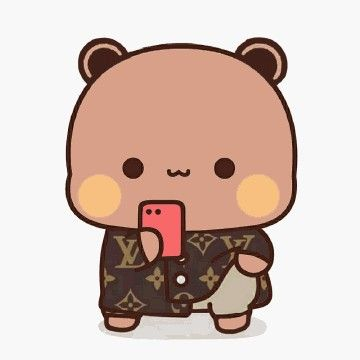

In [ ]:
from google.colab import files

# Upload an image file
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Read the uploaded image file
import io
from PIL import Image

image = Image.open(io.BytesIO(uploaded[file_name]))

# Display the uploaded image
image

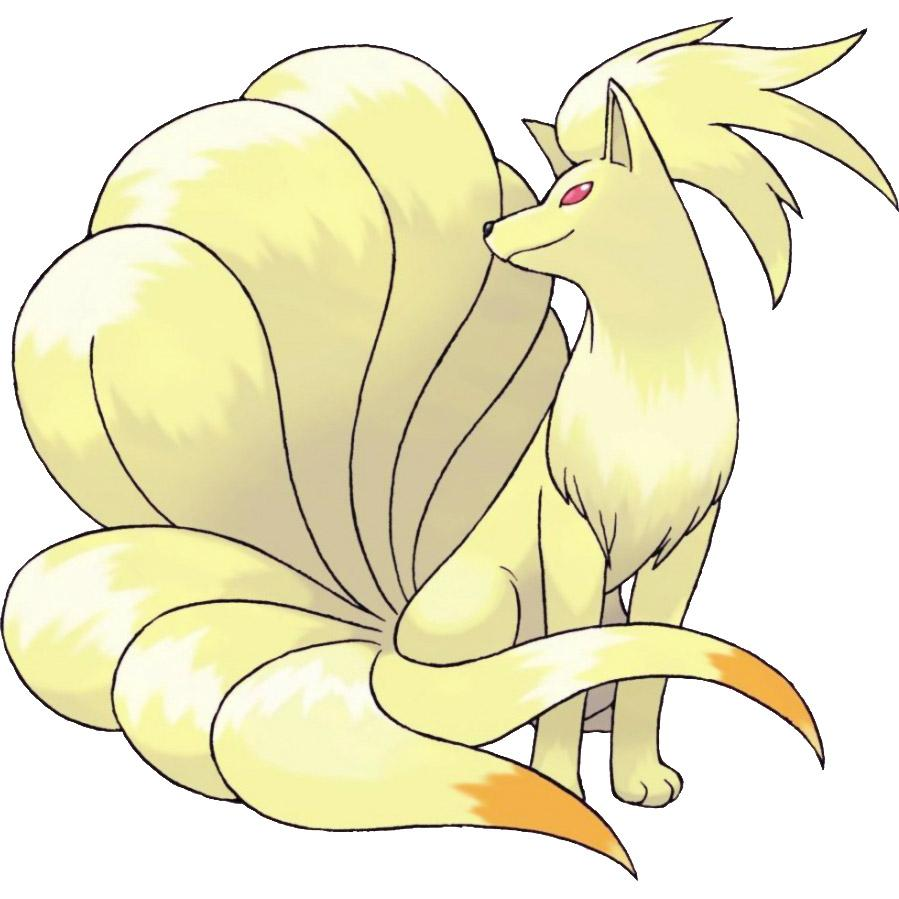

In [ ]:
image = testing_dataset[42]['image']
image

In [ ]:
testing_dataset[42]['text']

'A poised Ninetales with its luxurious golden-white tails fanned out gracefully.'

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model.generate(pixel_values=pixel_values, max_length=100)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

the logo for the new website, manu islam


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model_b_fine.to(device)

# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model_b_fine.generate(pixel_values=pixel_values, max_length=100)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a cute and friendly - looking brown and cream animated creature with a red nose and yellow cheeks, resembling a small, furry creature.


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model_large.to(device)

# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model_large.generate(pixel_values=pixel_values, max_length=100)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a close up of a cartoon bear holding a cell phone


# **Loading Model**

In [ ]:
import torch
from transformers import AutoProcessor, BlipForConditionalGeneration

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoProcessor, BlipForConditionalGeneration, BlipConfig

# Define the device
device = "cuda" if torch.cuda.is_available() else "cpu"

PATH = '/content/drive/MyDrive/Base_Pokemon.pth'

tokenizer = AutoTokenizer.from_pretrained("Salesforce/blip-image-captioning-base")

config = BlipConfig.from_pretrained('Salesforce/blip-image-captioning-base')
model_b_fine = BlipForConditionalGeneration(config)
model_b_fine.load_state_dict(torch.load(PATH))
# model_b_fine.eval()

<All keys matched successfully>

In [ ]:
model_large = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoProcessor, BlipForConditionalGeneration, BlipConfig

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoProcessor, BlipForConditionalGeneration, BlipConfig

# Define the device
device = "cuda" if torch.cuda.is_available() else "cpu"

PATH = "/content/drive/MyDrive/Large_Pokemon.pth"

tokenizer = AutoTokenizer.from_pretrained("Salesforce/blip-image-captioning-large")

config = BlipConfig.from_pretrained('Salesforce/blip-image-captioning-large')
model_l_fine = BlipForConditionalGeneration(config)
model_l_fine.load_state_dict(torch.load(PATH))
model_l_fine.eval()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-23): 24 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (projection): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (layer_norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1024,),

**Score of the** **models**

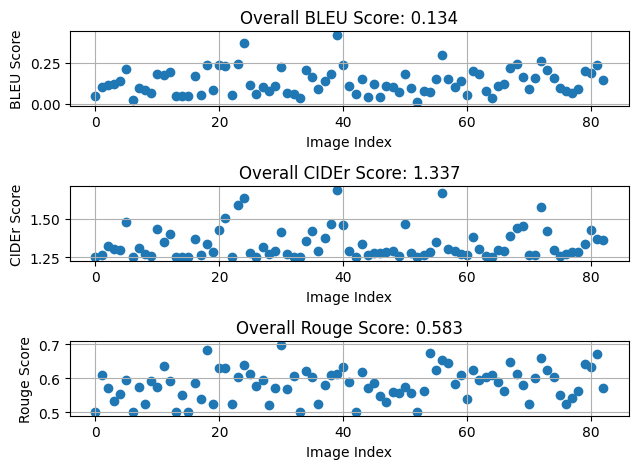

In [ ]:
# Base Model Scores
print_the_scores(model=model, processor=processor, testing_dataset=testing_dataset)

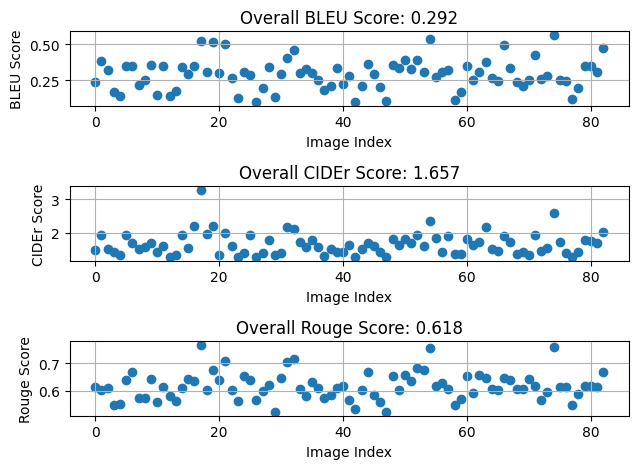

In [ ]:
# Base Fine-Tuned Model Scores
print_the_scores(model=model_b_fine, processor=processor, testing_dataset=testing_dataset)

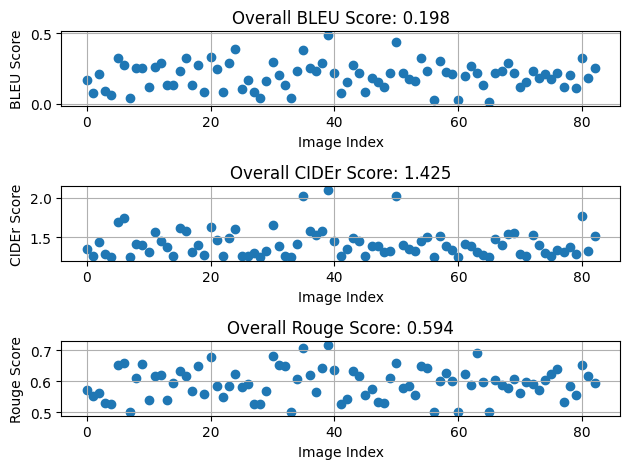

In [ ]:
# Large Model Scores
print_the_scores(model=model_large, processor=processor, testing_dataset=testing_dataset)

**Code for** **fintuning**

In [ ]:
#@title sentence_by_proxy (model, model_b, model_l, processor, image)
def sentence_by_proxy (model, model_b, model_l, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          logits_base = model(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_b(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_target = model_l(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
              logits_target + (logits_tuned - logits_base)
          )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
#@title print_the_scores_of_proxy_cosine(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_cosine(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = cosine_similarity(references, predictions)

    image_cidar_scores.append(result)

    image_cnt = image_cnt + 1

  flatten_scores = [score for sublist in image_cidar_scores for score in sublist]
  final_cidar_score = sum(flatten_scores) / len(flatten_scores)


  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Cosine Similarity")
  plt.title("Overall Cosine Similarity: %.3f" % final_cidar_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


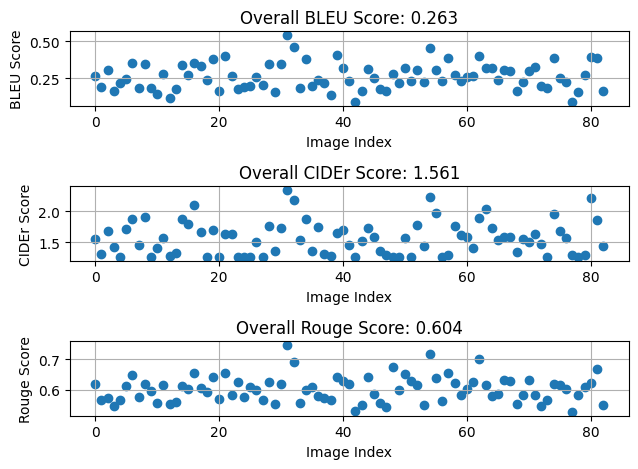

In [ ]:
#@title Score By Proxy-Tuning
print_the_scores_of_proxy(model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

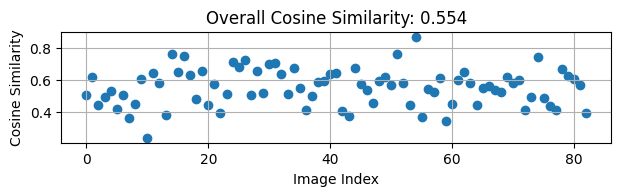

In [ ]:
#@title Score of Cosine Similarity By Proxy-Tuning
print_the_scores_of_proxy_cosine (model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

# **Z normalaization**

In [ ]:
model.cuda()
model_b_fine.cuda()
model_large.cuda()

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-23): 24 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (projection): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (layer_norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1024,),

In [ ]:
#@title sentence_by_proxy_Zscore (model, model_b, model_l, processor, image)
def sentence_by_proxy_Zscore (model, model_b, model_l, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          # Assuming logits_base, logits_tuned, and logits_target are obtained from your models
          logits_base = model(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]
          logits_tuned = model_b(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]
          logits_target = model_l(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]

          # Function to normalize a tensor using Z-score normalization
          def z_score_normalize(tensor):
              mean = tensor.mean()
              std = tensor.std()
              return (tensor - mean) / std

          # Apply Z-score normalization to each logits tensor
          logits_base_normalized = z_score_normalize(logits_base)
          logits_tuned_normalized = z_score_normalize(logits_tuned)
          logits_target_normalized = z_score_normalize(logits_target)

          # Perform the arithmetic operation with the normalized logits
          logits = logits_target_normalized + (logits_tuned_normalized - logits_base_normalized)

          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy__Zscore(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_Zscore(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_Zscore(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
#@title print_the_scores_of_proxy_cosine_Zscore(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_cosine_Zscore(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_Zscore(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = cosine_similarity(references, predictions)

    image_cidar_scores.append(result)

    image_cnt = image_cnt + 1

  flatten_scores = [score for sublist in image_cidar_scores for score in sublist]
  final_cidar_score = sum(flatten_scores) / len(flatten_scores)


  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Cosine Similarity")
  plt.title("Overall Cosine Similarity: %.3f" % final_cidar_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


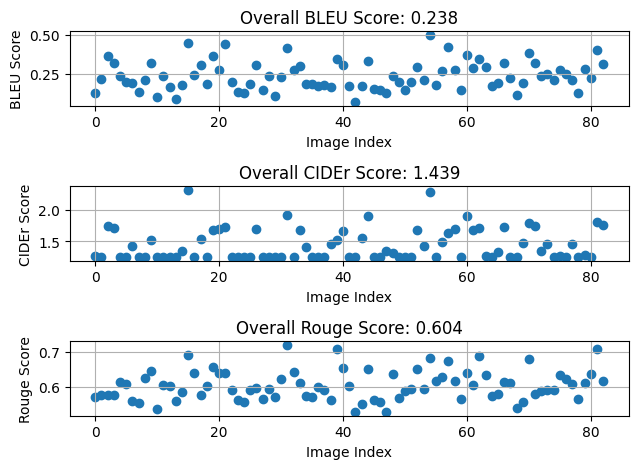

In [ ]:
# Print the score of proxy tuning by Z-Score
print_the_scores_of_proxy_Zscore(model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

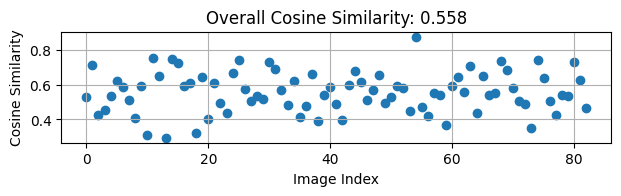

In [ ]:
# Print the score of proxy tuning by Z-Score <<<< Cosine Similarity>>>
print_the_scores_of_proxy_cosine_Zscore(model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

# **Min-Max Normalization**

In [ ]:
#@title sentence_by_proxy_min_maxscore (model, model_b, model_l, processor, image)
def sentence_by_proxy_min_maxscore (model, model_b, model_l, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          # Assuming logits_base, logits_tuned, and logits_target are obtained from your models
          logits_base = model(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]
          logits_tuned = model_b(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]
          logits_target = model_l(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]

          # def min_max_normalize(tensor):
          #   min_val = tensor.min()
          #   max_val = tensor.max()
          #   return (tensor - min_val) / (max_val - min_val)

          # Apply Z-score normalization to each logits tensor
          logits_base_normalized = min_max_normalize(logits_base)
          logits_tuned_normalized = min_max_normalize(logits_tuned)
          logits_target_normalized = min_max_normalize(logits_target)

          # Perform the arithmetic operation with the normalized logits
          logits = logits_target_normalized + (logits_tuned_normalized - logits_base_normalized)

          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy__min_maxscore(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_min_maxscore(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_min_maxscore(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
#@title print_the_scores_of_proxy_cosine_min_maxscore(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_cosine_min_maxscore(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_min_maxscore(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = cosine_similarity(references, predictions)

    image_cidar_scores.append(result)

    image_cnt = image_cnt + 1

  flatten_scores = [score for sublist in image_cidar_scores for score in sublist]
  final_cidar_score = sum(flatten_scores) / len(flatten_scores)


  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Cosine Similarity")
  plt.title("Overall Cosine Similarity: %.3f" % final_cidar_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

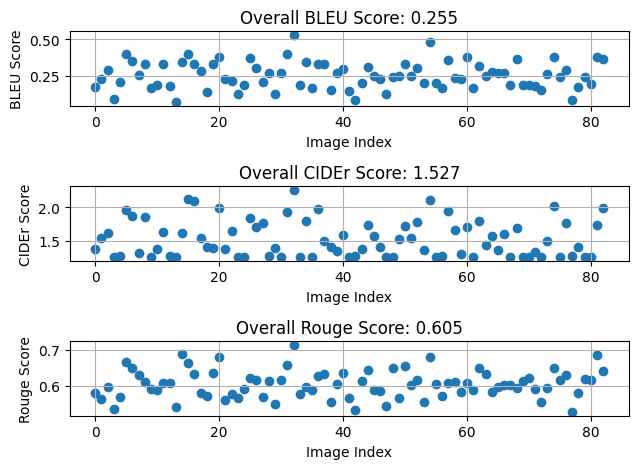

In [ ]:
# Print the score of proxy tuning by Min Maz Nrmalization
print_the_scores_of_proxy_min_maxscore (model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

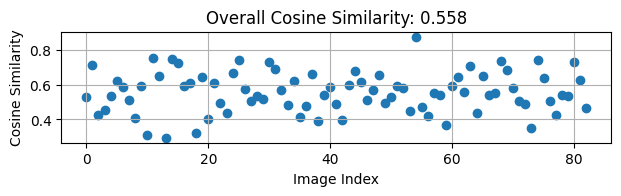

In [ ]:
# Print the score of proxy tuning by min _max <<<< Cosine Similarity>>>
print_the_scores_of_proxy_cosine_min_maxscore(model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

# **Decimal Scaling**

In [ ]:
#@title sentence_by_proxy_decimal_scaling (model, model_b, model_l, processor, image)
def sentence_by_proxy_decimal_scaling (model, model_b, model_l, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          # Assuming logits_base, logits_tuned, and logits_target are obtained from your models
          logits_base = model(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]
          logits_tuned = model_b(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]
          logits_target = model_l(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, -1, :]

          def decimal_scaling_normalize(tensor):
            # Find the maximum absolute value
            max_abs = torch.max(torch.abs(tensor))

            # Determine the power of 10
            power = int(torch.log10(max_abs).ceil())

            # Perform decimal scaling
            scaled_tensor = tensor / 10**power

            return scaled_tensor

          # Apply Z-score normalization to each logits tensor
          logits_base_normalized = decimal_scaling_normalize(logits_base)
          logits_tuned_normalized = decimal_scaling_normalize(logits_tuned)
          logits_target_normalized = decimal_scaling_normalize(logits_target)

          # Perform the arithmetic operation with the normalized logits
          logits = logits_target_normalized + (logits_tuned_normalized - logits_base_normalized)

          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy__decimal_scaling(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_decimal_scaling(model, model_b, model_l, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_decimal_scaling(model = model, model_b = model_b, model_l = model_l, processor = processor, image = image)
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

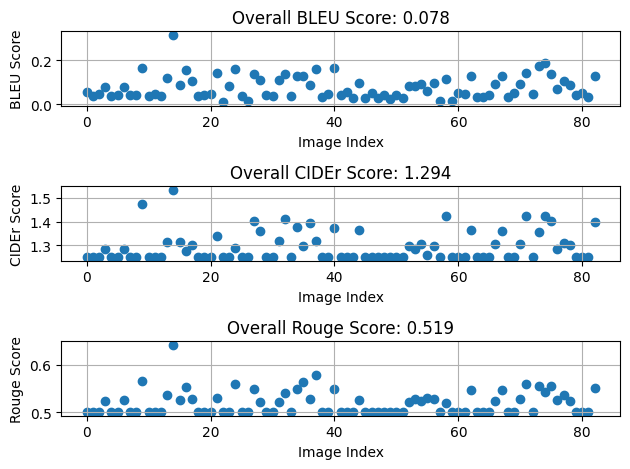

In [ ]:
# Print the score of proxy tuning by Min Maz Nrmalization
print_the_scores_of_proxy_decimal_scaling (model = model, model_b = model_b_fine, model_l = model_large, processor = processor, testing_dataset = testing_dataset)

Hi


HI


In [ ]:
!pip install evaluate
import evaluate, torch
bleu = evaluate.load('bleu')

In [ ]:
def give_me_bleu(testing_dataset):
  import matplotlib.pyplot as plt
  image_bleu_scores = []
  image_cnt = 1
  for id in testing_dataset:

    # print ("Image No: ", image_cnt)
    image = id['image']
    text = id['text']
    caption = Caption(model_l_fine, processor, image)

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    results = bleu.compute(predictions=predictions, references=references, max_order = 2)

    # if results['bleu'] > 0.7:
    #   print("Reference Text: ", text)
    #   print("Predicted Text: ", caption)

    image_bleu_scores.append(results['bleu'])
    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  return final_bleu_score

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [ ]:
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

In [ ]:
train_dataset = ImageCaptioningDataset(dataset, processor)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=3)
val_dataset = ImageCaptioningDataset(validition_dataset, processor)
val_dataloader = DataLoader(val_dataset, shuffle=True, batch_size=1)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_l_fine.cuda()

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-23): 24 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (projection): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (layer_norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1024,),

In [ ]:
print(torch.cuda.memory_allocated())

1886956032


In [ ]:
#@title Beep Function
from google.colab import output
def I_am_Done ():
  output.eval_js('new Audio("https://upload.wikimedia.org/wikipedia/commons/0/05/Beep-09.ogg").play()')

In [ ]:
I_am_Done ()

In [ ]:
PATH = "/content/drive/MyDrive/Large_Pokemon.pth"

In [ ]:
#@title Training Code
import torch
from statistics import mean
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, AutoConfig
from datasets import load_metric, Dataset, DatasetDict
from torch.utils.data import DataLoader
from tqdm.auto import tqdm  # Optional for progress bar

optimizer = torch.optim.AdamW(model_l_fine.parameters(), lr=2e-7,  weight_decay=0.05)

# Device selection (GPU if available)
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model_l_fine.to(device)

# Training hyperparameters
num_epochs = 5  # Adjust as needed
patience = 2  # Number of epochs to wait for improvement (for early stopping)
best_val_loss = float("inf")  # Initialize best validation loss
current_patience = 0  # Initialize current_patience outside the loop
image_cnt = 0
prev_score = 0.16651509870076264

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

def train(train_dataloader, val_dataloader):
  global image_cnt
  model_l_fine.train()
  train_loss = 0.0

  for batch in tqdm(train_dataloader, desc="Training"):  # Optional progress bar
    batch = {k: v.to(device) for k, v in batch.items()}

    # Forward pass
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)

    outputs = model_l_fine(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)
    loss = outputs.loss

    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    scheduler.step()  # Update learning rate
    train_loss = train_loss + loss.item()

  # Validation after each epoch
  val_loss = evaluate(val_dataloader)
  print(f'Epoch {epoch} - Train Loss: {train_loss / len(train_dataloader):.4f}, Val Loss: {val_loss:.4f}')

  # Early stopping (optional)
  global best_val_loss
  global current_patience
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    current_patience = 0  # Reset patience counter if loss improves
  else:
    current_patience += 1
  if current_patience >= patience:
    print(f'Early stopping at epoch {epoch} due to no improvement in validation loss')
    return  # Exit training loop if patience is exhausted

def evaluate(dataloader):
  model_l_fine.eval()
  eval_loss = 0.0
  image_cnt = 0
  with torch.no_grad():
    for batch in dataloader:
      batch = {k: v.to(device) for k, v in batch.items()}
      # if image_cnt > 50:
      #   break
      # else:
      #   image_cnt = image_cnt + 1
      input_ids = batch.pop("input_ids").to(device)
      pixel_values = batch.pop("pixel_values").to(device)

      outputs = model_l_fine(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)


      loss = outputs.loss

      eval_loss = eval_loss + loss.item()

  return eval_loss / len(dataloader)


for epoch in range(num_epochs):
  global prev_score
  train(train_dataloader, val_dataloader)
  score = give_me_bleu(testing_dataset)
  print ("Score: ", score)
  if score > prev_score :
    prev_score = score
    torch.save(model_l_fine.state_dict(), PATH)
I_am_Done ()


Training:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 0 - Train Loss: 0.0556, Val Loss: 0.1507
Score:  0.1506285936594118


Training:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 0.0549, Val Loss: 0.1509
Score:  0.16019917339802264


Training:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 2 - Train Loss: 0.0542, Val Loss: 0.1511
Early stopping at epoch 2 due to no improvement in validation loss
Score:  0.15153162279599344


Training:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 3 - Train Loss: 0.0536, Val Loss: 0.1511
Early stopping at epoch 3 due to no improvement in validation loss
Score:  0.14765232493667077


Training:   0%|          | 0/222 [00:00<?, ?it/s]

In [ ]:
#@title print_the_scores_of_proxy_min_max(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
r, p = [], []
def print_the_scores_of_proxy_min_max(model_base, model_tuned, model_target, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_min_max(model_base,model_tuned,model_target, processor = processor, image = image)
    # print(f'{image_cnt}: {caption}')
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)
    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all BLEU scores as a list
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
#@title sentence_by_proxy_logits_min_max_normalization (model, model_b, model_l, processor, image)
import torch
from transformers import AutoTokenizer, AutoModel, AutoProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def min_max_normalize(logits):
    min_vals = logits.min(dim=-1, keepdim=True).values
    max_vals = logits.max(dim=-1, keepdim=True).values
    normalized_logits = (logits - min_vals) / (max_vals - min_vals + 1e-9)  # add epsilon to avoid division by zero
    # print(normalized_logits)
    return normalized_logits

def sentence_by_proxy_min_max (model_base, model_tuned, model_target, processor, image):
    inputs = processor(images=image, return_tensors="pt").to(device)

    decoder_input_ids = [model_base.decoder_input_ids]
    input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

    predicted_ids = []

    with torch.no_grad():
        for i in range(50):
            logits_base = model_base(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]
            logits_tuned = model_tuned(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]
            logits_target = model_target(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]

            # print(f'{logits_base} {i}')

            # Apply min-max normalization
            logits_base = min_max_normalize(logits_base)
            logits_tuned = min_max_normalize(logits_tuned)
            logits_target = min_max_normalize(logits_target)

            logits = logits_target + (logits_tuned - logits_base)
            predicted_id = logits.argmax(-1)
            predicted_ids.append(predicted_id.item())

            # Add predicted id to input_ids
            input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
            if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
                break

    sentence = tokenizer.decode(predicted_ids, skip_special_tokens=True)
    return sentence

In [ ]:
model.cuda()
model_large.cuda()
model_b_fine.cuda()

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


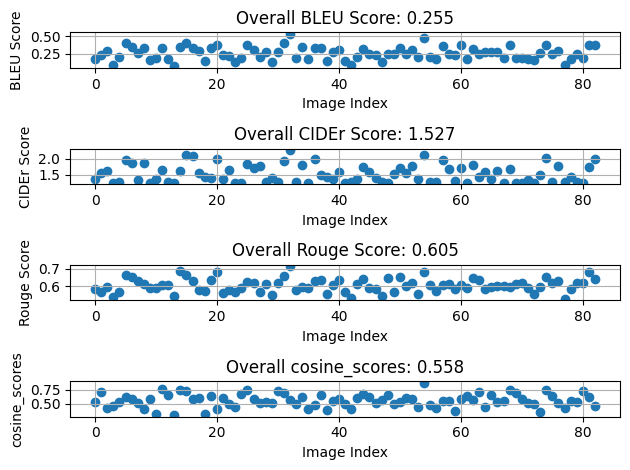

In [ ]:
# Print the score of proxy tuning by Min Maz Nrmalization
print_the_scores_of_proxy_min_max (model, model_b_fine, model_large, processor = processor, testing_dataset = testing_dataset)

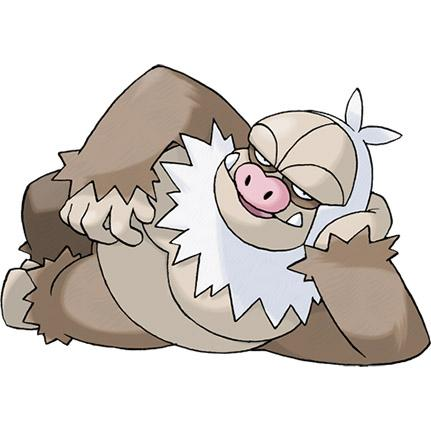

In [ ]:
image = testing_dataset[10]['image']
image

In [ ]:
# Base Model
print (Caption(model, processor, image))

a cute bear with a phone in his hand


In [ ]:
# Base fine tuned Model
print (Caption(model_b_fine, processor, image))

a cute and friendly - looking brown and cream animated creature with a red nose and yellow cheeks, resembling a small, furry creature.


In [ ]:
# Large Model
print (Caption(model_large, processor, image))

a close up of a cartoon bear holding a cell phone


In [ ]:
# Proxy Tuning
sentence = sentence_by_proxy(model, model_b_fine, model_large, processor, image)

In [ ]:
print(sentence)

" a cheerful brown and cream - colored animated creature with a small red object in its mouth. "


In [ ]:
# Proxy min max normalaization Tuning
sentence = sentence_by_proxy_min_maxscore (model, model_b_fine, model_large, processor, image)

In [ ]:
print (sentence)

a brightly lit - up illustration of a brown, bipedal animated creature with yellow eyes and a pattern on its body, along with a red nose and hands and feet, looking at a small, while standing with a small, looking at its mouth


In [ ]:
# Proxy with z score tuning
sentence = sentence_by_proxy_Zscore (model, model_b_fine, model_large, processor, image)
print (sentence)

a close up of a cartoon - like creature with a brown body, yellow cheeks, and black patterns on its body, along with yellow eyes and a small pink nose and hands and a small, hexagon on its chest, along with a small


In [ ]:
# Proxy with M1 tuning
sentence = sentence_by_proxy_da (model, model_b_fine, model_large, processor, image)
print (sentence)

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


" an illustration of kangaskhan, a brown, bipedal pokemon with yellow circular spots. " "


In [ ]:
# Proxy with M2 tuning
sentence = sentence_by_proxy_beta (model, model_b_fine, model_large, processor, image)
print (sentence)

a cheerful brown bear with a pink phone in its mouth


In [ ]:
#@title sentence_by_proxy_logits_da(model, model_b, model_l, processor, image)
def sentence_by_proxy_da(model_base, model_tuned, model_target, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model_base.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(100):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
              logits_target + (2.0 *(logits_tuned - logits_base))
          )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title sentence_by_proxy_logits_Beta(model, model_b, model_l, processor, image)
def sentence_by_proxy_beta (model_base, model_tuned, model_target, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model_base.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
             (0.5 + 1.0) * logits_target +(0.5 * (logits_tuned - logits_base))
          )
          # logits = (
          #    logits_target +((0.5 + 1.0) *  logits_tuned - 0.5 * logits_base)
          # )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence
